# 02 · A/B-style test — does delivery speed drive review scores?
**H0:** mean review score is the same for fast- and slow-delivered orders.
**H1:** they differ. We split orders at the median delivery time and test with a Welch t-test (score) + a two-proportion z-test (5-star rate), and report effect size.

In [15]:
# Anchor to the repo root so relative paths work whether this notebook is
# launched from the project folder or from notebooks/.
import os
from pathlib import Path
root = Path.cwd()
for _ in range(4):
    if (root / 'sql').exists():
        break
    root = root.parent
os.chdir(root)
print('Working directory:', Path.cwd())

Working directory: C:\Users\wassi\Desktop\retail-analytics


In [16]:
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')
con = duckdb.connect('data/olist.duckdb')

In [17]:
# Order-level table: delivery time + its review score
orders = con.execute('''
  SELECT o.order_id,
         DATE_DIFF('day', CAST(o.order_purchase_timestamp AS TIMESTAMP),
                          CAST(o.order_delivered_customer_date AS TIMESTAMP)) AS delivery_days,
         r.review_score
  FROM orders o
  JOIN reviews r ON o.order_id = r.order_id
  WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
''').df().drop_duplicates('order_id')

orders = orders.dropna(subset=['delivery_days','review_score'])
orders = orders[(orders['delivery_days']>=0) & (orders['delivery_days']<=60)]
print(f'{len(orders):,} orders with a delivery time and a review')
orders.head()

95,541 orders with a delivery time and a review


,order_id,delivery_days,review_score
0,73fc7af87114b39712e6da79b0a377eb,6,4
1,a548910a1c6147796b98fdf73dbeba33,9,5
2,f9e4b658b201a9f2ecdecbb34bed034b,13,5
3,658677c97b385a9be170737859d3511b,11,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,18,5


In [18]:
# Split at the median delivery time
med = orders['delivery_days'].median()
orders['group'] = np.where(orders['delivery_days'] <= med, 'fast', 'slow')
fast = orders.loc[orders.group=='fast', 'review_score']
slow = orders.loc[orders.group=='slow', 'review_score']
print(f'median split at {med:.0f} days  |  fast n={len(fast):,}  slow n={len(slow):,}')
print(f'fast mean score = {fast.mean():.3f}')
print(f'slow mean score = {slow.mean():.3f}')

median split at 10 days  |  fast n=49,622  slow n=45,919
fast mean score = 4.381
slow mean score = 3.925


### Test 1 — Welch t-test on mean review score + Cohen's d

In [19]:
t, p = stats.ttest_ind(fast, slow, equal_var=False)

def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2)/(na+nb-2))
    return (a.mean()-b.mean())/sp

d = cohens_d(fast, slow)
print(f'Welch t = {t:.2f}')
print(f'p-value = {p:.2e}')
print(f"Cohen's d = {d:.3f}")
print('Significant at 0.05' if p < 0.05 else 'Not significant at 0.05')

Welch t = 55.43
p-value = 0.00e+00
Cohen's d = 0.362
Significant at 0.05


### Test 2 — two-proportion z-test on the 5-star rate
(computed directly so no statsmodels dependency)

In [20]:
c_fast, n_fast = (fast==5).sum(), len(fast)
c_slow, n_slow = (slow==5).sum(), len(slow)
p_fast, p_slow = c_fast/n_fast, c_slow/n_slow
p_pool = (c_fast + c_slow) / (n_fast + n_slow)
se = np.sqrt(p_pool*(1-p_pool)*(1/n_fast + 1/n_slow))
z = (p_fast - p_slow) / se
pval = 2*(1 - stats.norm.cdf(abs(z)))
print(f'5-star rate  fast = {p_fast:.1%}   slow = {p_slow:.1%}')
print(f'z = {z:.2f}   p = {pval:.2e}')

5-star rate  fast = 66.6%   slow = 51.5%
z = 47.49   p = 0.00e+00


### Visualize

C:\Users\wassi\AppData\Local\Temp\ipykernel_33760\1620781931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(orders, x='group', y='review_score', errorbar='ci',
C:\Users\wassi\AppData\Local\Temp\ipykernel_33760\1620781931.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(prop, x='group', y='five', ax=axes[1], palette=['#4C78A8','#E45756'])


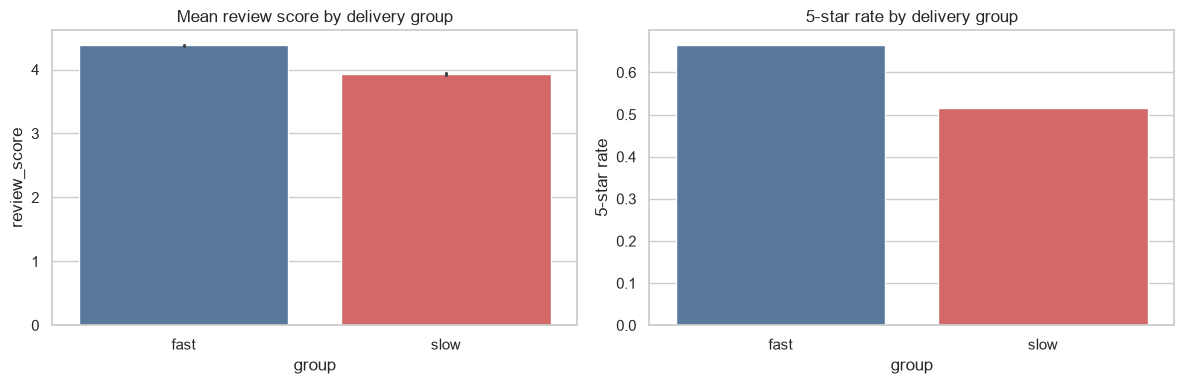

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.barplot(orders, x='group', y='review_score', errorbar='ci',
            ax=axes[0], palette=['#4C78A8','#E45756'])
axes[0].set_title('Mean review score by delivery group')
prop = (orders.assign(five=orders.review_score==5)
        .groupby('group')['five'].mean().reset_index())
sns.barplot(prop, x='group', y='five', ax=axes[1], palette=['#4C78A8','#E45756'])
axes[1].set_title('5-star rate by delivery group'); axes[1].set_ylabel('5-star rate')
plt.tight_layout(); plt.savefig('dashboard/screenshots/ab_delivery_review.png', dpi=120); plt.show()

## Conclusion & recommendation
_Fill in with your numbers:_ if fast-delivered orders score significantly higher (low p, meaningful d), the recommendation writes itself — **delivery speed is a satisfaction lever**. Since satisfied customers are likelier to return/refer, cutting delivery time is a concrete way to attack the retention problem found in the EDA.